# General mapper pipeline

**Author:** Erik Amézquita

**Date:** November 2025

This is a short notebook on how to generate Mapper graphs with a variety of parameters. Mapper is one of the many tools available from Topological Data Analysis (TDA). In this case, the analysis is targeted to RNAseq data. Choosing the right parameters is a combination of math, art, and some luck. This is by no means an exhaustive list of things to try, but it (hopefully) will provide a good starting point from which finer analyses can be devised.

## On the usage of this Notebook

You don't need to know how to code to use this notebook. If you've managed to get a open this very notebook with Jupyter, you've already done the hardest part. You will only need to change three numbers and one/two names in Part IV. Look for the sparkle symbols (&#10024;) below that will encourage where to change values.

- You only need to click run for *all* cells.
- You only need to run Parts I thru III *once* (running them again won't do anything bad but will take longer).
- You will need to edit the code for Part IV, and Part IV only: it will be easy, I promise.
- After you edit Part IV, you'll need to run Part V and act on Part VI
- You will repeat Parts IV thru VI to explore the data through Mapper

## Some observations on what to expect

There might be exceptions, but in general you might expect

- Changing `lens` (filter function) will affect the **most** the final color distribution (and possibly shape) of the mapper graph
- As well as choosing between using one or two lens functions at time
- The higher the number of `bins`, the more nodes you'll have in the mapper
- The higher the `overlap` percentage, the more edges you'll have between nodes
- Low `eps` value for clustering can result in a low percentage of unique genes represented in the mapper graph

---

# Part I: Imports

We start importing some standard libraries and sublibraries for non-TDA stuff. For the mapper-specific computations, we'll use `kmapper.`

In [1]:
import os
import itertools
import numpy as np
import kmapper as km
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import cluster

import utils
from importlib import reload

---

# Part II: Wrangling the data with purpose

The data contains RNAseq read counts for 56k genes and 6 experiments with 2 repetitions each (12 rice samples in total). These samples follow the naming convention:
- B = Resistant line
- I = Susceptible line 1
- Z = Susceptible line 2
- M = Mock
- A = Bacterial inoculation
- 24 = RNA collected 24 hours after infection

Thus,
- BA24 = Resistant line, Bacterial inoculation, RNA collected 24 hours after infection
- IM24 = Susceptible line 1, Mock, RNA collected 24 hours after infection

&#10071;**Important:** Make sure that Ajay's data is inside the `raw` folder of your downloaded github folder. I did not want to publicly post his data without his explicit consent.

## Overall goal

The goal is to figure out which genes are the most differentially expressed across the six experiments. Identifying such genes is crucial to later explore pathways that will enventually result in rice varieties that are genetically immune to bacterial attacks.

The standard way to assess if a gene is differentially expressed between two samples is to check for its *fold-change* ratio:

$$\text{FC} = \frac{\text{Expression of Sample A}}{\text{Expression of Sample B}}$$

For a given gene  for example, if sample $A$ has an expression value of 10 and sample $B$ only has 5, then $FC = 2$, which literally means that the expression level from $B$ to $A$ has increased 2-fold. In principle, we are looking for genes with high $FC$ values. However, if the expression level of $B$ is very close to 0 (because the gene is not that important to begin with or there was a problem in the sequencing pipeline), then its $FC$ will be very high. We don't want that.

On top of that, in this case there are only 2 replicates per experiment, so doing any meaningful statistics will be hard. I'm not a bioinformatician nor a statistician, though. I read quickly through [DESeq2](https://doi.org/10.1186/s13059-014-0550-8) (the gold standard) for inspiration on a crude way to compute $FC$ values and adjust them for cases where sample $B$ is poorly expressed. 

In short, I computed adjusted $FC$ scores to assess for differential expression levels for
- BA versus BM
- IA versus IM
- ZA versus ZM
- BA versus IA
- BA versus ZA
- BM versus IM
- BM versus ZM

That is, 7 $FC$s are computed and then they are simply added to have a single number per gene.

We finally take the logarithm of this number to obtain a single $LFC$ value, *log-fold-change*.

## A word on bioinformatics and normalization

Regardless of how $LFC$ scores are computed, we must make sure that we are actually comparing apples to apples. The original reading/expression values must be comparable between samples. There are two ways to achieve this:

A common way is to transform read counts into **TPM** (transcripts per million). [Read here if you are curious on what TPM means and how it is computed](https://www.rna-seqblog.com/rpkm-fpkm-and-tpm-clearly-explained/). My understanding is that TPM is good to check which genes are consistently highly/lowly expressed across samples. 

However, we are **not** looking for *highly* expressed genes but for *differentially* expressed genes. TPM normalization fails to account for differences in library composition. This is a considerable issue when dealing with samples from different tissues, as there are housekeeping genes that will naturally be expressed in $A$ and not $B$. [DESeq2](https://doi.org/10.1186/s13059-014-0550-8) handles that problem. [Check this video](https://www.youtube.com/watch?v=UFB993xufUU) on how DESeq2 normalizes read data.

That being said: **If you have access to better differential expression assessment numbers, use those**.

In case you don't have your own DESeq2-like numbers, I wrote in `foldchange` a crude way to penalize genes with poor expression values: Say you want to compare all replicates from population $A$ vs. all replicates of population $B$. The function `foldchange` then does:

1. Compute $\mu(A) - \text{SE}(A)$ and $\mu(B) - \text{SE}(B)$, the mean minus the standard error of the *read counts* for $A$ and $B$, respectively. These differences are always positive.
2. Re-scale all these differences so that the minimum is $Q_\alpha$ and the max is $Q_{1-\alpha}$. These are the quantiles of the differences. The idea is to remove the influence of outliers. These will be our attenuation factors. By default, I use $\alpha = 0.01$. 
3. Cap the attenuation factors to max value 1.
4. Compute $FC_1 = A/B$ and $FC_2 = B/A$
5. Take $FC = \text{attenuation}\times\max(FC_1 , FC_2)$. This will guarantee that differentially expressed genes will always have a large $FC$ value.

The overall idea is that poorly expressed genes _aka_ genes with low read count number will end up with very small attenuation factors, that will ultimately annul spurious high $FC$ values. Genes with read counts with very high variance _aka_ high standard error are also penalized.

## Read, transform, and clean the count data

- Read the count data
- Transform the read counts to TPM
- Remove genes that have the exact same expression across all samples
- Remove the genes that have less than 1 TPM expressed on average across all samples
- Compute $FC$s for the 7 pairs mentioned above, add them, and log-transform it.
- Bound the highest values for better visualization

In [2]:
fs = 12
src = os.pardir + os.sep + 'raw' + os.sep
dst = os.pardir + os.sep + 'outputs' + os.sep
if not os.path.isdir(dst):
    os.mkdir(dst)

# List the name of the lines, their repetitions
# and pairs to compare
tpm = pd.read_csv(src + 'TPM_combined.csv', index_col=0)
deseq2 = pd.read_csv(src + 'DESeq2_combined.csv', index_col=0)
filters = pd.read_csv(src + 'Combined_gene_filters.csv', index_col=0)

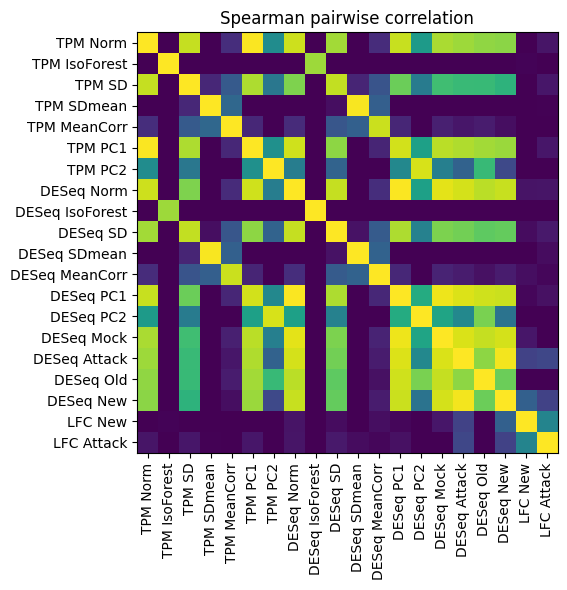

In [11]:
corrmethods = ['spearman']
fig, ax = plt.subplots(1,len(corrmethods),figsize=(6,6), sharex=True, sharey=True)
ax = np.atleast_1d(ax)
for i in range(len(corrmethods)):
    corr = filters.corr(method=corrmethods[i], numeric_only=True)
    ax[i].set_title(corrmethods[i].title() + ' pairwise correlation', fontsize=fs)
    ax[i].imshow(corr, cmap='viridis', vmin=0, vmax=1)
    ax[i].set_yticks(range(len(corr)), corr.index, rotation=0);
    ax[i].set_xticks(range(len(corr)), corr.index, rotation=90);
fig.tight_layout()

In [9]:
filters.describe()

,TPM Norm,TPM IsoForest,TPM SD,TPM SDmean,TPM MeanCorr,TPM PC1,TPM PC2,DESeq Norm,DESeq IsoForest,DESeq SD,DESeq SDmean,DESeq MeanCorr,DESeq PC1,DESeq PC2,DESeq Mock,DESeq Attack,DESeq Old,DESeq New,LFC New,LFC Attack
count,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000,1.972900e+04,1.972900e+04,1.972900e+04,19729.000000,19729.000000,19729.000000,19729.000000,1.972900e+04,1.972900e+04,19729.000000,19729.000000,19729.000000,1.972900e+04,19729.000000,19729.000000
mean,305.119816,0.118296,27.102886,0.576721,0.408769,5.278164e-10,7.050526e-10,1.137908e+04,0.116539,974.413623,0.569527,0.405593,-1.426192e-09,2.391786e-10,1751.481544,1842.136542,1658.738158,1.978006e+03,0.005951,-0.003677
std,1856.499093,0.082419,211.225759,0.418931,0.128604,4.265889e+00,2.620947e+00,5.881580e+04,0.080580,6931.364666,0.419330,0.127447,4.230639e+00,2.726327e+00,8947.184024,10045.547435,7013.858163,1.334524e+04,0.328425,0.151233
min,1.361888,-0.378774,0.126204,0.072261,0.093184,-7.653099e-01,-2.272398e+02,1.106015e+02,-0.373439,17.309655,0.056461,0.094444,-9.668227e-01,-2.197136e+02,0.000000,0.000000,0.000000,0.000000e+00,-3.759770,-3.360843
25%,31.522835,0.116053,2.307649,0.271055,0.301955,-6.900777e-01,-2.025613e-01,1.223331e+03,0.118302,91.301969,0.260936,0.297990,-8.683890e-01,-3.266928e-01,154.446010,149.542897,153.599007,1.457355e+02,-0.059905,-0.022983
50%,87.639797,0.153117,5.579869,0.450115,0.433760,-5.391526e-01,-1.560950e-01,3.631712e+03,0.148620,226.673451,0.443089,0.428329,-6.464952e-01,-2.404519e-01,561.549251,553.229429,555.834645,5.506161e+02,-0.001258,-0.000009
75%,217.266467,0.161794,15.025982,0.780948,0.519919,-1.933271e-01,-3.015862e-02,9.412973e+03,0.157901,610.723974,0.777325,0.515815,-1.177727e-01,-4.486445e-03,1517.266138,1531.843840,1512.609118,1.539080e+03,0.055290,0.025004
max,159293.672695,0.170666,21135.953035,4.419165,0.607030,3.147557e+02,1.124312e+02,5.412514e+06,0.167516,720416.454648,4.469451,0.602943,3.225858e+02,1.440528e+02,717406.096222,975019.592589,535465.045606,1.410966e+06,4.237258,1.382800


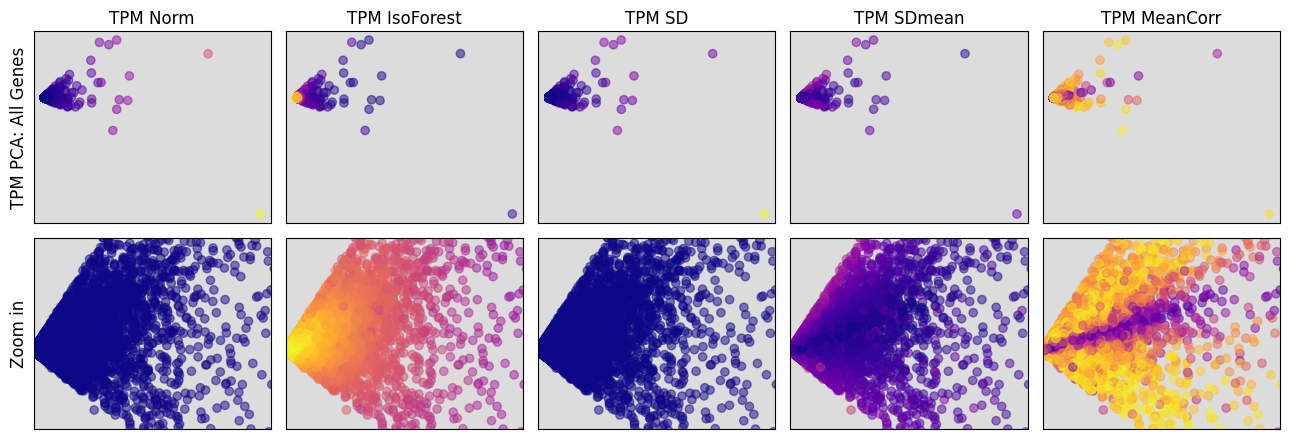

In [19]:
alpha = 0.05
tpmpca = filters[[f'TPM PC{i}' for i in range(1,3) ]].to_numpy()
qs = np.quantile(tpmpca, [alpha, 1-alpha], axis=0)
iqr = (qs[1] - qs[0])*1.5

fig, ax = plt.subplots(2,5, figsize=(13,4.5))     
for i in range(ax.shape[1]):
    ax[0,i].set_title(filters.columns[i], fontsize=fs)
    ax[0,i].scatter(*tpmpca.T, c=filters.iloc[:,i], cmap='plasma', marker='o', alpha=0.5)
    ax[1,i].scatter(*tpmpca.T, c=filters.iloc[:,i], cmap='plasma', marker='o', alpha=0.5)
    ax[1,i].set_xlim(np.min(tpmpca[:,0]), qs[1,0] + iqr[0])
    ax[1,i].set_ylim(qs[0,1] - iqr[1], qs[1,1] + iqr[1])
for a in ax.ravel():
    a.tick_params(labelleft=False, left=False, bottom=False, labelbottom=False)
    a.set_facecolor('gainsboro')
ax[0,0].set_ylabel('TPM PCA: All Genes', fontsize=fs)
ax[1,0].set_ylabel('Zoom in', fontsize=fs)

fig.tight_layout()

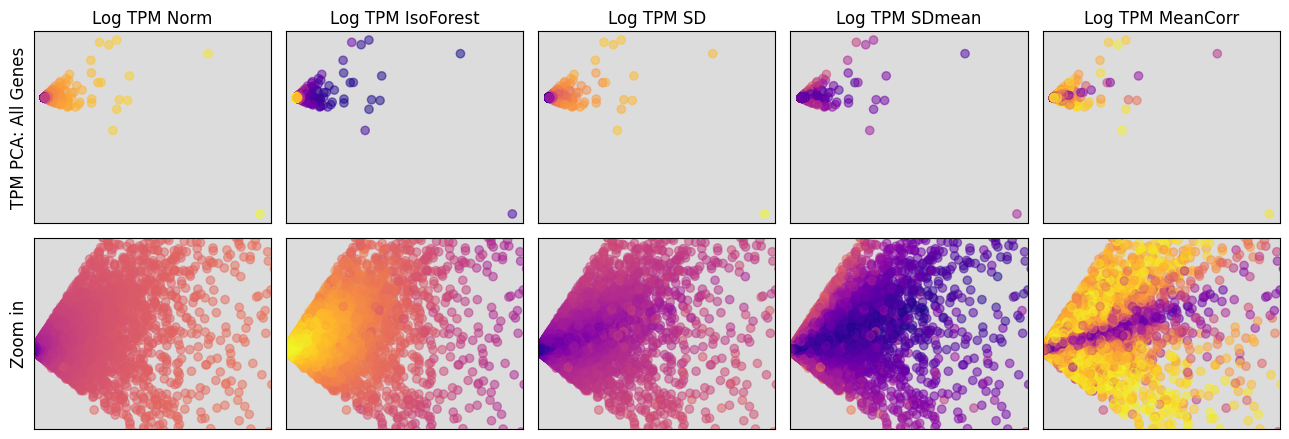

In [20]:
fig, ax = plt.subplots(2,5, figsize=(13,4.5))
for i in range(ax.shape[1]):
    c = np.log(filters.iloc[:,i] - filters.iloc[:,i].min() + 1)
    ax[0,i].set_title('Log ' + filters.columns[i], fontsize=fs)
    ax[0,i].scatter(*tpmpca.T, c=c, cmap='plasma', marker='o', alpha=0.5)
    ax[1,i].scatter(*tpmpca.T, c=c, cmap='plasma', marker='o', alpha=0.5)
    ax[1,i].set_xlim(np.min(tpmpca[:,0]), qs[1,0] + iqr[0])
    ax[1,i].set_ylim(qs[0,1] - iqr[1], qs[1,1] + iqr[1])
for a in ax.ravel():
    a.tick_params(labelleft=False, left=False, bottom=False, labelbottom=False)
    a.set_facecolor('gainsboro')
ax[0,0].set_ylabel('TPM PCA: All Genes', fontsize=fs)
ax[1,0].set_ylabel('Zoom in', fontsize=fs)
fig.tight_layout()

----
## What about DESeq2 data?

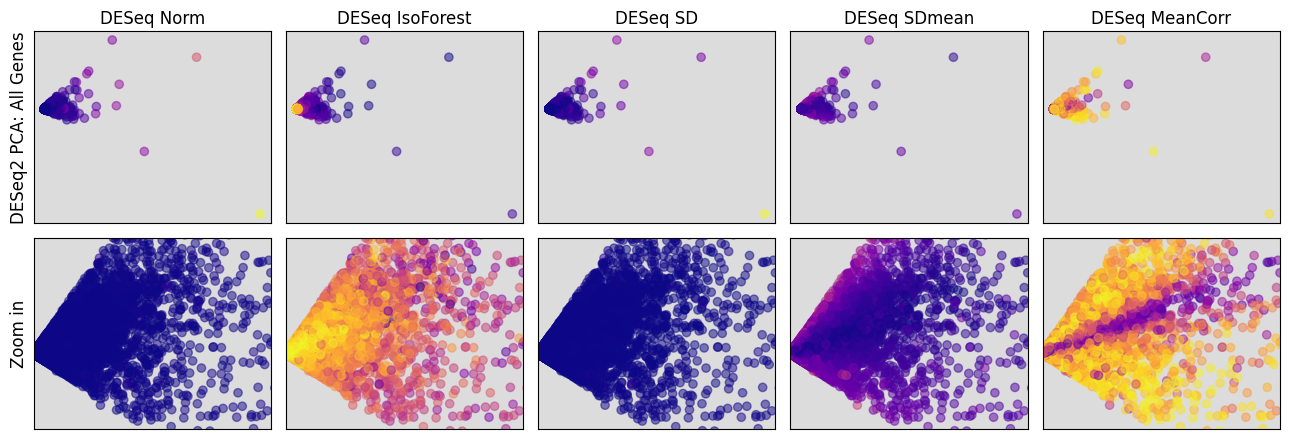

In [21]:
deseqpca = filters[[f'DESeq PC{i}' for i in range(1,3) ]].to_numpy()
qs = np.quantile(deseqpca, [alpha, 1-alpha], axis=0)
iqr = (qs[1] - qs[0])*1.5

fig, ax = plt.subplots(2,5, figsize=(13,4.5))     
for i in range(ax.shape[1]):
    ax[0,i].set_title(filters.columns[7+i], fontsize=fs)
    ax[0,i].scatter(*deseqpca.T, c=filters.iloc[:,i], cmap='plasma', marker='o', alpha=0.5)
    ax[1,i].scatter(*deseqpca.T, c=filters.iloc[:,i], cmap='plasma', marker='o', alpha=0.5)
    ax[1,i].set_xlim(np.min(deseqpca[:,0]), qs[1,0] + iqr[0])
    ax[1,i].set_ylim(qs[0,1] - iqr[1], qs[1,1] + iqr[1])
for a in ax.ravel():
    a.tick_params(labelleft=False, left=False, bottom=False, labelbottom=False)
    a.set_facecolor('gainsboro')
ax[0,0].set_ylabel('DESeq2 PCA: All Genes', fontsize=fs)
ax[1,0].set_ylabel('Zoom in', fontsize=fs)

fig.tight_layout()

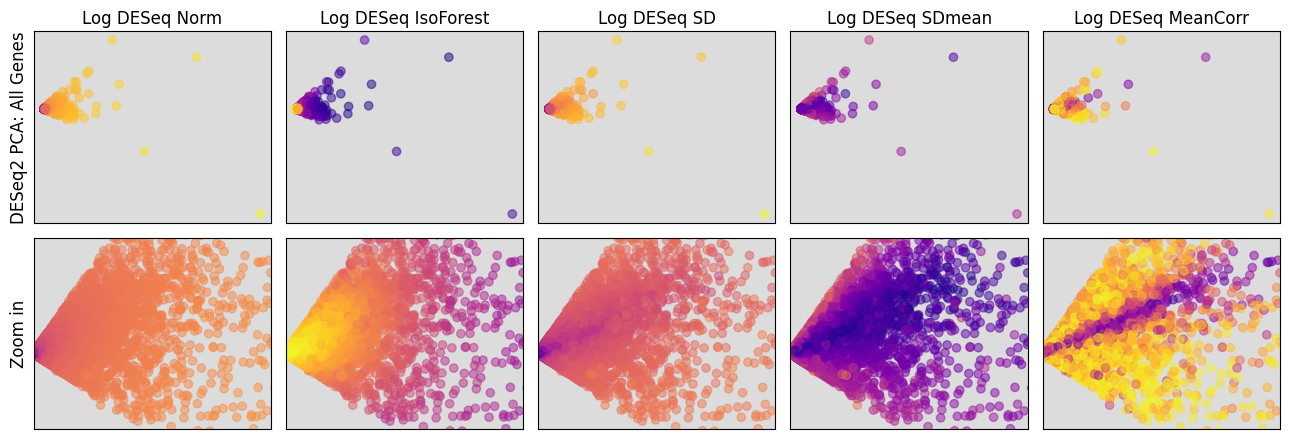

In [29]:
fig, ax = plt.subplots(2,5, figsize=(13,4.5))
for i in range(ax.shape[1]):
    c = np.log(filters.iloc[:,7+i] - filters.iloc[:,7+i].min() + 1)
    ax[0,i].set_title('Log ' + filters.columns[7+i], fontsize=fs)
    ax[0,i].scatter(*deseqpca.T, c=c, cmap='plasma', marker='o', alpha=0.5)
    ax[1,i].scatter(*deseqpca.T, c=c, cmap='plasma', marker='o', alpha=0.5)
    ax[1,i].set_xlim(np.min(deseqpca[:,0]), qs[1,0] + iqr[0])
    ax[1,i].set_ylim(qs[0,1] - iqr[1], qs[1,1] + iqr[1])
for a in ax.ravel():
    a.tick_params(labelleft=False, left=False, bottom=False, labelbottom=False)
    a.set_facecolor('gainsboro')
ax[0,0].set_ylabel('DESeq2 PCA: All Genes', fontsize=fs)
ax[1,0].set_ylabel('Zoom in', fontsize=fs)
fig.tight_layout()

### Adding log-valued filters where relevant

In [31]:
for source in ['TPM', 'DESeq']:
    for value in ['Norm', 'SD', 'SDmean']:
        c = source + ' ' + value
        val = np.log(filters[c] - filters[c].min() + 1)
        filters['Log ' + c] = val
filters.head()

,TPM Norm,TPM IsoForest,TPM SD,TPM SDmean,TPM MeanCorr,TPM PC1,TPM PC2,DESeq Norm,DESeq IsoForest,DESeq SD,...,DESeq Old,DESeq New,LFC New,LFC Attack,Log TPM Norm,Log TPM SD,Log TPM SDmean,Log DESeq Norm,Log DESeq SD,Log DESeq SDmean
MSU,,,,,,,,,,,,,,,,,,,,,
LOC_Os01g01010,131.991057,0.154889,3.580910,0.142340,0.200516,-0.387945,-0.109064,9229.244273,0.134938,268.245908,...,1570.033706,1811.693110,0.035152,-0.008280,4.879989,1.493961,0.067733,9.118186,5.529176,0.091896
LOC_Os01g01030,8.835790,0.162671,0.744504,0.484860,0.375902,-0.742786,-0.194563,494.897888,0.158746,40.934130,...,99.657941,73.758702,-0.004354,0.000952,2.136991,0.481376,0.345431,5.954013,3.203741,0.348926
LOC_Os01g01040,105.608376,0.162225,2.493893,0.123604,0.170590,-0.460831,-0.131982,6476.548248,0.144538,171.925034,...,1119.522372,1318.972023,0.032436,-0.009263,4.656305,1.214227,0.050069,8.758875,5.047387,0.079510
LOC_Os01g01050,112.109452,0.158991,4.026636,0.189841,0.352453,-0.446085,-0.090538,5224.688847,0.150170,169.317827,...,996.793774,942.580751,-0.011550,-0.030152,4.716242,1.589323,0.111166,8.539950,5.030491,0.108208
LOC_Os01g01060,635.632145,0.002212,49.213015,0.437872,0.533942,0.988607,0.920886,12866.055596,0.098983,873.984346,...,2864.297905,1595.771044,-0.253927,-0.010317,6.454051,3.913758,0.311602,9.453793,6.754225,0.277482


---
## Log-fold change distribution

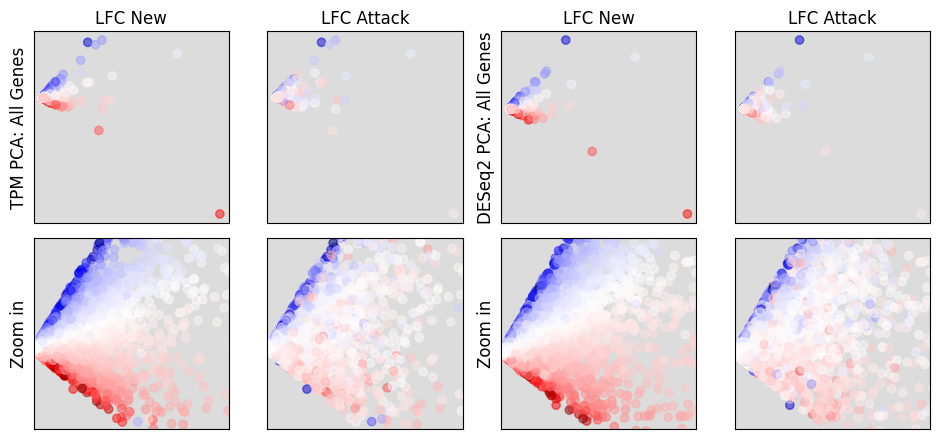

In [26]:
fig, ax = plt.subplots(2, 4, figsize=(9.5,4.5))

for i,c in enumerate(['LFC New', 'LFC Attack']):
    vmax = filters[c].abs().max()
    for k,pca in enumerate([tpmpca, deseqpca]):
        ax[0,i+2*k].set_title(c, fontsize=fs)
        ax[0,i+2*k].scatter(*pca.T, c=filters[c], cmap='seismic', marker='o', alpha=0.5, vmin=-vmax, vmax=vmax)
        ax[1,i+2*k].scatter(*pca.T, c=filters[c], cmap='seismic', marker='o', alpha=0.5, vmin=-vmax, vmax=vmax)
        ax[1,i+2*k].set_xlim(np.min(pca[:,0]), qs[1,0] + iqr[0])
        ax[1,i+2*k].set_ylim(qs[0,1] - iqr[1], qs[1,1] + iqr[1])

for a in ax.ravel():
    a.tick_params(labelleft=False, left=False, bottom=False, labelbottom=False)
    a.set_facecolor('gainsboro')

ax[0,0].set_ylabel('TPM PCA: All Genes', fontsize=fs)
ax[1,0].set_ylabel('Zoom in', fontsize=fs)

ax[0,2].set_ylabel('DESeq2 PCA: All Genes', fontsize=fs)
ax[1,2].set_ylabel('Zoom in', fontsize=fs)

fig.tight_layout()

Bright colored points (yellow) correspond to high $FC$s, while dim colored points correspond to low $FC$s. All I see in reality is a large clump with some offshoots. There seems to be effectively a continuum left-to-right matching an increase of $FC$.

Can we say more with mapper?

---

# Part III: Mapper setup

Before we get into Mapper, let's do some setup. You'll just need to run the code below only once.

As you know by now, Mapper has lots and lots of moving pieces. This is good because it let's us adjust the pieces to whatever goal we have in mind. But it is bad because it is not so obvious what is the right combination of ingredients.

Your task is to explore what do different moving pieces do by making lots and lots of graphs and keeping a log of your observations.

In [27]:
# Code to get mapper started object
mymapper = km.KeplerMapper(verbose=1)

# Define Nerve
nerve = km.GraphNerve(min_intersection=1)

KeplerMapper(verbose=1)


## Filter (lens) functions

The most important moving piece of mapper is the lens (filter function). Different lenses will highlight different features of the data structure. Remember that a lens is essentially a way to assign a *single* number to each of the 20K genes we are dealing with. Below are 6 functions to get us started:

- **Lens 1 (isolation)**
    - Isolation forest index: How *anomalous* is the gene? Is its expression level common or rare compared to the rest?
- **Lens 2 (sd)**
    - Standard deviation of the expression levels
- **Lens 3 (sd mean)**
    - Standard deviation divided the mean
- **Lens 4 (high low):**
    - Expression difference between the 2nd highest and 2nd lowest samples
- **Lens 5 (pc1):**
    - PC1 value (it already expresses 90% of the total variance)
- **Lens 6 (euclidean):**
    - $L_2$ norm _aka_ Euclidean norm: how close to 0 expression is the gene?
 
&#10071; **Important:** Make note of the name in the parenthesis. Note that the names are all lowercase.

---

<span style='font-size:4em;'>&#10024;</span>

# Part IV: Defining concrete values for mapper

Now the fun really begins: time for **you** to choose some moving parts and see what happens. There's an example below.

## Define a clustering method: DBSCAN (`eps`)

There are several [clustering algorithms available](https://scikit-learn.org/stable/api/sklearn.cluster.html) out there. And each of these algorithms has its own moving pieces, oh my. We will focus on just one to keep things simple: DBSCAN. Usually matches your intuition. Kind of the gold standard. The one parameter that matters is epsilon (`eps` or &#949;):

- &#10024; `eps`: How close must be the points to be considered?
    - Low `eps` will favor lots of small clusters.
    - Large `eps` will tend to give you few, large clusters.
    - Try values `eps`: 0.1, 0.2, 0.3, 0.4, 0.5, 0.6

## Define the number of bins (`bins`) and their overlap (`overlap`)

- &#10024; `bins`: Into how many bins are we going to split the data?
    - Low `bins` will produce few nodes resulting in a possibly too simple graph
    - Large `bins` will produce more nodes resulting in a possibly too complex graph
    - Try values `bins`: 20, 30, 40, ..., and so on till 120
    - You can try values larger than 120, but they might take longer to compute
 
- &#10024; `overlap`: How much overlap&mdash;percentage-wise&mdash; is there between consecutive bins?
    - Low `overlap` will only link truly close nodes but will produce few edges
    - High `overlap` will produce many more edges, but this might muddle the picture
    - Try values `overlap`: 0.2, 0.3, ..., 0.8
 
## Decide the filter function to use `lens`

This is possibly what will influence the final mapper shape the most. And you can even choose if you will be considering one or two filter functions at a time. (In principle you can consider 3,4,5,etc. filter functions at a time, but computations get super long and complex).

You can choose from 12 options available. The 6 regular filters and their 6 log versions, as defined above.

1. isolation
1. sd
1. sd mean
1. high low
1. pc1
1. euclidean

- &#10024; `lens`: Select one or two lens names. If you choose two, the order does not matther.

**Important:** Syntax is important to avoid code errors below.

- Make sure that you type the lens names exactly as indicated. 
- *Each* of the lens names should be between apostrophes `'` (you'll see that the text is a reddish color)
- If you use two lenses, these are separated by a comma `,`
- The whole thing always should be between square brackets `[ ]`

# Let's look at an example

You will only need to make edits to one of the cells below. 

Say that we want to compute the mapper graph using 100 bins, with 30% overlap between them, and a clustering epsilon of 0.3. We want to use only one filter: the standard deviation filter. Then the cell below should look like:

```python
eps = 0.3
bins = 100
overlap = 30
lens = [ 'sd' ]
```

<span style='font-size:2em;'>&#9889;</span> That's it. That's all the code you have to write! You don't have change anything else.

## Another example

Now say we want to use 120 bins, with 50% overlap between them, with an epsilon of 0.2, and *two* filters: standard deviation *and* the log-transformed Isolation Forest index.

```python
eps = 0.2
bins = 120
overlap = 50
lens = [ 'sd' , 'log isolation' ]
```

# &#11088; &#11088; Your turn &#11088; &#11088;

Remember to edit **and** run the cell. There should be a message printed that confirms that your edits were successful

In [32]:
filters.columns

Index(['TPM Norm', 'TPM IsoForest', 'TPM SD', 'TPM SDmean', 'TPM MeanCorr',
       'TPM PC1', 'TPM PC2', 'DESeq Norm', 'DESeq IsoForest', 'DESeq SD',
       'DESeq SDmean', 'DESeq MeanCorr', 'DESeq PC1', 'DESeq PC2',
       'DESeq Mock', 'DESeq Attack', 'DESeq Old', 'DESeq New', 'LFC New',
       'LFC Attack', 'Log TPM Norm', 'Log TPM SD', 'Log TPM SDmean',
       'Log DESeq Norm', 'Log DESeq SD', 'Log DESeq SDmean'],
      dtype='object')

In [34]:
filters.describe()

,TPM Norm,TPM IsoForest,TPM SD,TPM SDmean,TPM MeanCorr,TPM PC1,TPM PC2,DESeq Norm,DESeq IsoForest,DESeq SD,...,DESeq Old,DESeq New,LFC New,LFC Attack,Log TPM Norm,Log TPM SD,Log TPM SDmean,Log DESeq Norm,Log DESeq SD,Log DESeq SDmean
count,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000,1.972900e+04,1.972900e+04,1.972900e+04,19729.000000,19729.000000,...,19729.000000,1.972900e+04,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000
mean,305.119816,0.118296,27.102886,0.576721,0.408769,5.278164e-10,7.050526e-10,1.137908e+04,0.116539,974.413623,...,1658.738158,1.978006e+03,0.005951,-0.003677,4.438115,2.084446,0.375969,8.070309,5.387288,0.381961
std,1856.499093,0.082419,211.225759,0.418931,0.128604,4.265889e+00,2.620947e+00,5.881580e+04,0.080580,6931.364666,...,7013.858163,1.334524e+04,0.328425,0.151233,1.460503,1.229203,0.245648,1.558761,1.554157,0.244583
min,1.361888,-0.378774,0.126204,0.072261,0.093184,-7.653099e-01,-2.272398e+02,1.106015e+02,-0.373439,17.309655,...,0.000000,0.000000e+00,-3.759770,-3.360843,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.522835,0.116053,2.307649,0.271055,0.301955,-6.900777e-01,-2.025613e-01,1.223331e+03,0.118302,91.301969,...,153.599007,1.457355e+02,-0.059905,-0.022983,3.439166,1.157335,0.181317,7.015469,4.317386,0.186044
50%,87.639797,0.153117,5.579869,0.450115,0.433760,-5.391526e-01,-1.560950e-01,3.631712e+03,0.148620,226.673451,...,555.834645,5.506161e+02,-0.001258,-0.000009,4.469097,1.864648,0.320528,8.166816,5.348838,0.326875
75%,217.266467,0.161794,15.025982,0.780948,0.519919,-1.933271e-01,-3.015862e-02,9.412973e+03,0.157901,610.723974,...,1512.609118,1.539080e+03,0.055290,0.025004,5.379458,2.766305,0.535726,9.138132,6.387577,0.542826
max,159293.672695,0.170666,21135.953035,4.419165,0.607030,3.147557e+02,1.124312e+02,5.412514e+06,0.167516,720416.454648,...,535465.045606,1.410966e+06,4.237258,1.382800,11.978503,9.958772,1.676518,15.504204,13.487562,1.688802


In [83]:
# Edit the code here

eps = 0.6
bins = 20
overlap = 30
lens = ['Log TPM Norm', 'TPM SDmean']

# That's it. 
# Now you just need to run the cell below and check the resulting mapper graph
# Remember to run the cell below every time you edit these parameters

print('All set to compute mapper with:\n + # Bins:\t{}\n + Overlap%:\t{}\n + Filters:\t{}\n + Epsilon:\t{}'.format(bins,overlap,lens,eps))

All set to compute mapper with:
 + # Bins:	20
 + Overlap%:	30
 + Filters:	['Log TPM Norm', 'TPM SDmean']
 + Epsilon:	0.6


---

# Part V: Run and visualize

Congrats! You are done with editing. Now you just need to run the cell below to compute the actual mapper graph.

In [84]:
# Just run it

lens = sorted(lens)
# Define clustering algorithm
clusterer = cluster.DBSCAN(eps=eps, metric='correlation', n_jobs=1)
cmethod = clusterer.__module__.split('.')[-1][1:].lower() + '{:.1f}'.format(clusterer.eps).replace('.',',')
#clusterer = cluster.KMeans(n_clusters=2, random_state=42)

# Define mapper cover
cover = km.cover.Cover(n_cubes=bins, perc_overlap=overlap/100.)

# Define lens function
lensf = filters[lens].values.squeeze()

# Create mapper graph with nodes, edges and meta-information.
graph = mymapper.map(lens=lensf,
                     X=tpm,
                     clusterer=clusterer,
                     cover=cover,
                     nerve=nerve,
                     precomputed=False,
                     remove_duplicate_nodes=True)

nunique = len(np.unique(list(itertools.chain(*[ graph['nodes'][key] for key in graph['nodes'] ]))))
print('\nMapper graph contains {} unique genes [{:.2f}% of total]\n\n'.format(nunique, 100*nunique/len(tpm)))

# Specify file to save html output

key = '+'.join(lens).replace(' ','_')
ktitle = ' and '.join(lens)

fpath =  dst + "{}_B{}_Ov{}_{}.".format(key, bins, overlap, cmethod)
figtitle = "{}; #Bins {}; Overlap: {}%; DBSCAN &#949; {}".format(ktitle, bins, overlap, clusterer.eps)

_ = mymapper.visualize(graph,
                       path_html=fpath + 'html',
                       title=figtitle,
                       color_values=filters['LFC New'].values,
                       colorscale=None,
                       color_function_name=["log-fold change"],
                       nbins = 10)
                       #include_searchbar=True)

Mapping on data shaped (19729, 27) using lens shaped (19729, 2)

Creating 400 hypercubes.
No duplicate nodes found to remove.


Created 522 edges and 157 nodes in 0:00:00.968812.

Mapper graph contains 19534 unique genes [99.01% of total]


Wrote visualization to: ../outputs/Log_TPM_Norm+TPM_SDmean_B20_Ov30_dbscan0,6.html


# &#9889; You did it

If no errors were shown, you should find the generated mapper graph inside the `outputs` folder. It is an HTML file that you can open with any web browser. The file name should tell you the filter(s) used, the number of bins, overlap, and `eps` parameter for DBSCAN.

---

# Part VI: Making sense of the mapper graph

Check the number of unique genes being included in the graph. This is mentioned in the cell above. You should see a message that reads something like:

```
Mapper graph contains 24288 unique genes [99.14% of total]
```

`kmapper` will not include genes that are a cluster of their own. This happens whenever a gene is waaay too different from the rest and mapper is unable to cluster it/pair it with somebody else. While missing a few genes here and there is almost unavoidable, make sure that mapper is including a good chunk of the total. In this case, we are including 99.2%, which is pretty good. 

You can also check that number in the actual mapper graph:

1. Open the graph
1. Click on the `[+] Mapper Summary` tab
1. You should see a number next to `Unique Samples`: the closer this number is to 24,498 (100%), the better.

## Mapper shape

Finally, check the mapper graph. Look for anything that looks *interesting*. In general, simple strands are boring (unless the coloring pattern is much more interesting than a simple continuum). 
- Bifurcations are cool.
- Flares are cool
- Large loops are cool

Also look if colors, especially yellow colored-nodes, follow an interesting placement within the graph.

**Note:** The node size in the graph is **not** proportional to the number of genes clustered in it. What might look like an 

## &#9889; Now go and make some pretty mapper graphs!

# Rinse and repeat: Edit Part IV, and run again Parts V and VI

---

&copy; Copyright 2025, Erik Am&eacute;zquita (University of Missouri)

# IGNORE EVERYTHING BELOW: Some scratch code to figure things out

In [68]:
import json
with open(fpath + 'json', 'w') as f:
    json.dump(graph,f)

In [71]:
print(graph.keys())
print(graph['nodes'].keys())
key = 'cube179_cluster0'
print(len(graph['nodes']))
if key in graph['nodes']:
    print(graph['nodes'][key])

dict_keys(['nodes', 'links', 'simplices', 'meta_data', 'meta_nodes'])
dict_keys(['cube179_cluster0', 'cube180_cluster0', 'cube181_cluster0', 'cube193_cluster0', 'cube193_cluster1', 'cube194_cluster0', 'cube195_cluster0', 'cube205_cluster0', 'cube206_cluster0', 'cube219_cluster0', 'cube220_cluster0', 'cube221_cluster0', 'cube232_cluster0', 'cube232_cluster1', 'cube233_cluster0', 'cube233_cluster1', 'cube234_cluster0', 'cube234_cluster1', 'cube235_cluster0', 'cube235_cluster1', 'cube236_cluster0', 'cube238_cluster0', 'cube244_cluster0', 'cube244_cluster1', 'cube245_cluster0', 'cube245_cluster1', 'cube246_cluster0', 'cube246_cluster1', 'cube247_cluster0', 'cube247_cluster1', 'cube248_cluster0', 'cube248_cluster1', 'cube254_cluster0', 'cube255_cluster0', 'cube256_cluster0', 'cube257_cluster0', 'cube257_cluster1', 'cube258_cluster0', 'cube258_cluster1', 'cube259_cluster0', 'cube263_cluster0', 'cube264_cluster0', 'cube265_cluster0', 'cube266_cluster0', 'cube266_cluster1', 'cube267_cluster0',

In [72]:
minnode = len(tpm)
maxnode = 0

for key in graph['nodes']:
    aux = min(graph['nodes'][key])
    if aux < minnode:
        minnode = aux
        ix = key
    aux = max(graph['nodes'][key])
    if aux > maxnode:
        maxnode = aux
        jx = key

print(minnode, ix, '\n', maxnode, jx)

0 cube301_cluster0 
 24497 cube301_cluster0


In [78]:
print(graph['links'].keys(), len(graph['links'].keys()), sep='\n')
key = 'cube301_cluster0'
key = 'cube179_cluster0'
if key in graph['links']:
    print(graph['links'][key])

dict_keys(['cube179_cluster0', 'cube180_cluster0', 'cube181_cluster0', 'cube193_cluster0', 'cube194_cluster0', 'cube205_cluster0', 'cube206_cluster0', 'cube219_cluster0', 'cube220_cluster0', 'cube221_cluster0', 'cube232_cluster0', 'cube232_cluster1', 'cube233_cluster0', 'cube233_cluster1', 'cube234_cluster0', 'cube234_cluster1', 'cube235_cluster0', 'cube235_cluster1', 'cube236_cluster0', 'cube244_cluster0', 'cube244_cluster1', 'cube245_cluster0', 'cube245_cluster1', 'cube246_cluster0', 'cube246_cluster1', 'cube247_cluster0', 'cube247_cluster1', 'cube248_cluster0', 'cube254_cluster0', 'cube255_cluster0', 'cube256_cluster0', 'cube257_cluster0', 'cube257_cluster1', 'cube258_cluster0', 'cube258_cluster1', 'cube259_cluster0', 'cube263_cluster0', 'cube264_cluster0', 'cube265_cluster0', 'cube266_cluster0', 'cube266_cluster1', 'cube267_cluster0', 'cube267_cluster1', 'cube271_cluster0', 'cube272_cluster0', 'cube273_cluster0', 'cube274_cluster0', 'cube274_cluster1', 'cube279_cluster0', 'cube280_

In [76]:
np.array(list(map(len, graph['links'].values())))

array([2, 2, 1, 3, 2, 3, 2, 2, 3, 1, 3, 2, 4, 3, 4, 4, 3, 3, 1, 4, 4, 4,
       4, 4, 4, 2, 4, 2, 3, 4, 6, 4, 4, 2, 3, 1, 3, 4, 5, 3, 3, 1, 2, 3,
       5, 7, 2, 3, 3, 6, 3, 3, 1, 3, 6, 2, 2, 3, 4, 1, 1, 3, 3, 1, 4, 3,
       3])

In [48]:
sets = {'cube179_cluster0', 'cube180_cluster0', 'cube181_cluster0', 'cube193_cluster0', 'cube194_cluster0', 'cube205_cluster0', 'cube206_cluster0', 'cube219_cluster0', 'cube220_cluster0', 'cube221_cluster0', 'cube232_cluster0', 'cube232_cluster1', 'cube233_cluster0', 'cube233_cluster1', 'cube234_cluster0', 'cube234_cluster1', 'cube235_cluster0', 'cube235_cluster1', 'cube236_cluster0', 'cube244_cluster0', 'cube244_cluster1', 'cube245_cluster0', 'cube245_cluster1', 'cube246_cluster0', 'cube246_cluster1', 'cube247_cluster0', 'cube247_cluster1', 'cube248_cluster0', 'cube254_cluster0', 'cube255_cluster0', 'cube256_cluster0', 'cube257_cluster0', 'cube257_cluster1', 'cube258_cluster0', 'cube258_cluster1', 'cube259_cluster0', 'cube263_cluster0', 'cube264_cluster0', 'cube265_cluster0', 'cube266_cluster0', 'cube266_cluster1', 'cube267_cluster0', 'cube267_cluster1', 'cube271_cluster0', 'cube272_cluster0', 'cube273_cluster0', 'cube274_cluster0', 'cube274_cluster1', 'cube279_cluster0', 'cube280_cluster0', 'cube281_cluster0', 'cube281_cluster1', 'cube282_cluster0', 'cube284_cluster0', 'cube285_cluster0', 'cube286_cluster0', 'cube286_cluster1', 'cube289_cluster0', 'cube290_cluster0', 'cube291_cluster0', 'cube291_cluster1', 'cube293_cluster0', 'cube294_cluster0', 'cube295_cluster0', 'cube297_cluster0', 'cube298_cluster0', 'cube301_cluster0', 'cube303_cluster0'}


['cube195_cluster0']

In [51]:
key = 'cube193_cluster1'
print(graph['nodes'][key])
key in graph['links']

[18180, 13418, 20113, 9235, 20122, 18973, 927]


False